# 1. Gaussian Blur 

가우시안 블러. 이미지를 뿌옇게 만드는 가장 대표적인 방법이다. 
가장 기본이 되는 수식은 다음과 같다. 
중심점 주변의 픽셀을 불러와서 가우시안 값을 가중치로 곱해주는 것이다. 
중심점의 이동은 슬라이딩윈도우와 동일해서, 가중치의 곱셈(컨볼루션)이 끝나면 한픽셀 옆으로 이동한다. 
$$
B = I * G  \\

B(x,y) =\sum_{i=-k}^{k} \sum_{j=-k}^{k} G(i,j)\,I(x-i,y-j)
$$

$$
G(x,y)
=
\frac{1}{2\pi\sigma^2}
\exp\left(
-\frac{x^2}{2\sigma_x^2}  
-\frac{y^2}{2\sigma_y^2}
\right)
$$

대표적인 $3 \times 3$ Gaussian 근사 커널은 다음과 같다.

$$
K
=
\frac{1}{16}
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}
$$

이를 실제 가중치 값으로 나타내면 다음과 같다.

$$
K
=
\begin{bmatrix}
0.0625 & 0.125 & 0.0625 \\
0.125 & 0.25 & 0.125 \\
0.0625 & 0.125 & 0.0625
\end{bmatrix}
$$

중심 픽셀의 가중치는 $0.25$로 가장 크고, 모서리 픽셀의 가중치는
$0.0625$로 가장 작다.

커널의 모든 가중치 합은 다음과 같이 $1$이다.

$$
\sum_{i=-1}^{1}
\sum_{j=-1}^{1}
K(i,j)
=
1
$$

가우시안 함수 자체는 전체 영영게서 적분하면 1이 되어야 한다. 그러나 실제 적용할때는 픽셀을 유한하게 잘라서 샘플링하게 되므로 샘플링된 값이 정확히 1이 아닌경우가 발생한다. (그런가?) 그래서 다시 커널의 합을 $1$로 정규화 하는 과정을 거치는 편이 좋다. 이를 통해 이미지의 전체적인 값이 변하지 않도록 하기 위해서이다.

## 더 알아보기 

가우시안 블러는 가우시안 커널과 입력 이미지의 컨볼루션 연산이다.
즉, 가우시안 커널을 이용한 컨볼루션, 또는 가우시안 필터링이라고 말한다. 

그럼 다른 대표적인 커널들은 뭐가 있을까. 

### Edge Detection Kernel

Edge detection 필터는 이미지 밝기가 급격하게 변하는 지점을 검출한다.  
일반적으로 커널의 가중치 합은 $0$이며, 밝기가 일정한 영역에서는 출력값이 $0$에 가까워진다.

대표적인 수평 방향 밝기 변화 검출용 Sobel kernel은 다음과 같다.

$$
K_x
=
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

이 커널의 가중치 합은 다음과 같이 $0$이다.

$$
\sum_i \sum_j K_x(i,j)
=
-1+0+1-2+0+2-1+0+1
=
0
$$

입력 이미지의 밝기가 모두 일정한 값 $c$라고 하면, 출력값은 다음과 같다.

$$
\begin{aligned}
B(x,y)
&=
c\sum_i\sum_j K_x(i,j) \\
&=
c\cdot0 \\
&=
0
\end{aligned}
$$

따라서 밝기가 일정한 영역은 제거되고, 가로 방향으로 밝기가 변하는 경계가 강조된다.

수직 방향 밝기 변화를 검출하는 Sobel kernel은 다음과 같다.

$$
K_y
=
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

두 방향의 결과를 각각 $G_x$와 $G_y$라고 하면, 최종 경계 강도는 다음과 같이 계산할 수 있다.

$$
G
=
\sqrt{
G_x^2+G_y^2
}
$$

계산량을 줄이기 위해 다음과 같은 근사식도 사용할 수 있다.

$$
G
\approx
|G_x|+|G_y|
$$

### Sharpening Kernel

Sharpening 필터는 중심 픽셀을 강조하고 주변 픽셀의 영향을 빼서 이미지의 경계와 세부 정보를 선명하게 만든다.

대표적인 sharpening kernel은 다음과 같다.

$$
K_{\mathrm{sharp}}
=
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

이 커널의 가중치 합은 다음과 같이 $1$이다.

$$
\sum_i\sum_j K_{\mathrm{sharp}}(i,j)
=
0-1+0-1+5-1+0-1+0
=
1
$$

입력 이미지의 밝기가 모두 일정한 값 $c$인 경우, 출력은 다음과 같다.

$$
\begin{aligned}
B(x,y)
&=
c\sum_i\sum_j K_{\mathrm{sharp}}(i,j) \\
&=
c\cdot1 \\
&=
c
\end{aligned}
$$

따라서 일정한 밝기 영역은 대체로 유지되고, 밝기 변화가 있는 경계 부분은 강조된다.

이 sharpening kernel은 원본 이미지에서 Laplacian 성분을 빼는 형태로도 해석할 수 있다.

$$
I_{\mathrm{sharp}}
=
I-\nabla^2 I
$$

4-neighbor Laplacian kernel을 다음과 같이 정의하면,

$$
K_{\mathrm{lap}}
=
\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

sharpening kernel은 다음 관계를 가진다.

$$
\begin{aligned}
K_{\mathrm{sharp}}
&=
K_{\mathrm{identity}}
-
K_{\mathrm{lap}} \\
&=
\begin{bmatrix}
0 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0
\end{bmatrix}
-
\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix} \\
&=
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{bmatrix}
\end{aligned}
$$

In [1]:
!pip install opencv-python-headless

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 11.2 MB/s eta 0:00:00m eta 0:00:010:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.3.1 requires opencv-python-headless==4.10.0.84, but you have opencv-python-headless 5.0.0.93 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


/home/lairpeteryksong/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
from pathlib import Path

image_path = Path("./data/rgb_rawlight.png")

if not image_path.exists():
    raise FileNotFoundError(
        f"이미지 파일이 존재하지 않습니다: {image_path}"
    )

print("사용할 이미지 경로:", image_path)
print("파일 크기:", image_path.stat().st_size, "bytes")

사용할 이미지 경로: data/rgb_rawlight.png
파일 크기: 1482227 bytes


In [6]:
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError(f"이미지를 읽지 못했습니다: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("이미지 크기:", image_rgb.shape)

이미지 크기: (720, 1280, 3)


In [21]:
blur_3 = cv2.GaussianBlur(image_rgb, (3, 3), sigmaX=0, sigmaY=0)
blur_7 = cv2.GaussianBlur(image_rgb, (7, 7), sigmaX=0, sigmaY=0)
blur_15 = cv2.GaussianBlur(image_rgb, (15, 15), sigmaX=0, sigmaY=0)
blur_sigma5 = cv2.GaussianBlur(image_rgb, (15, 15), sigmaX=5, sigmaY=5)


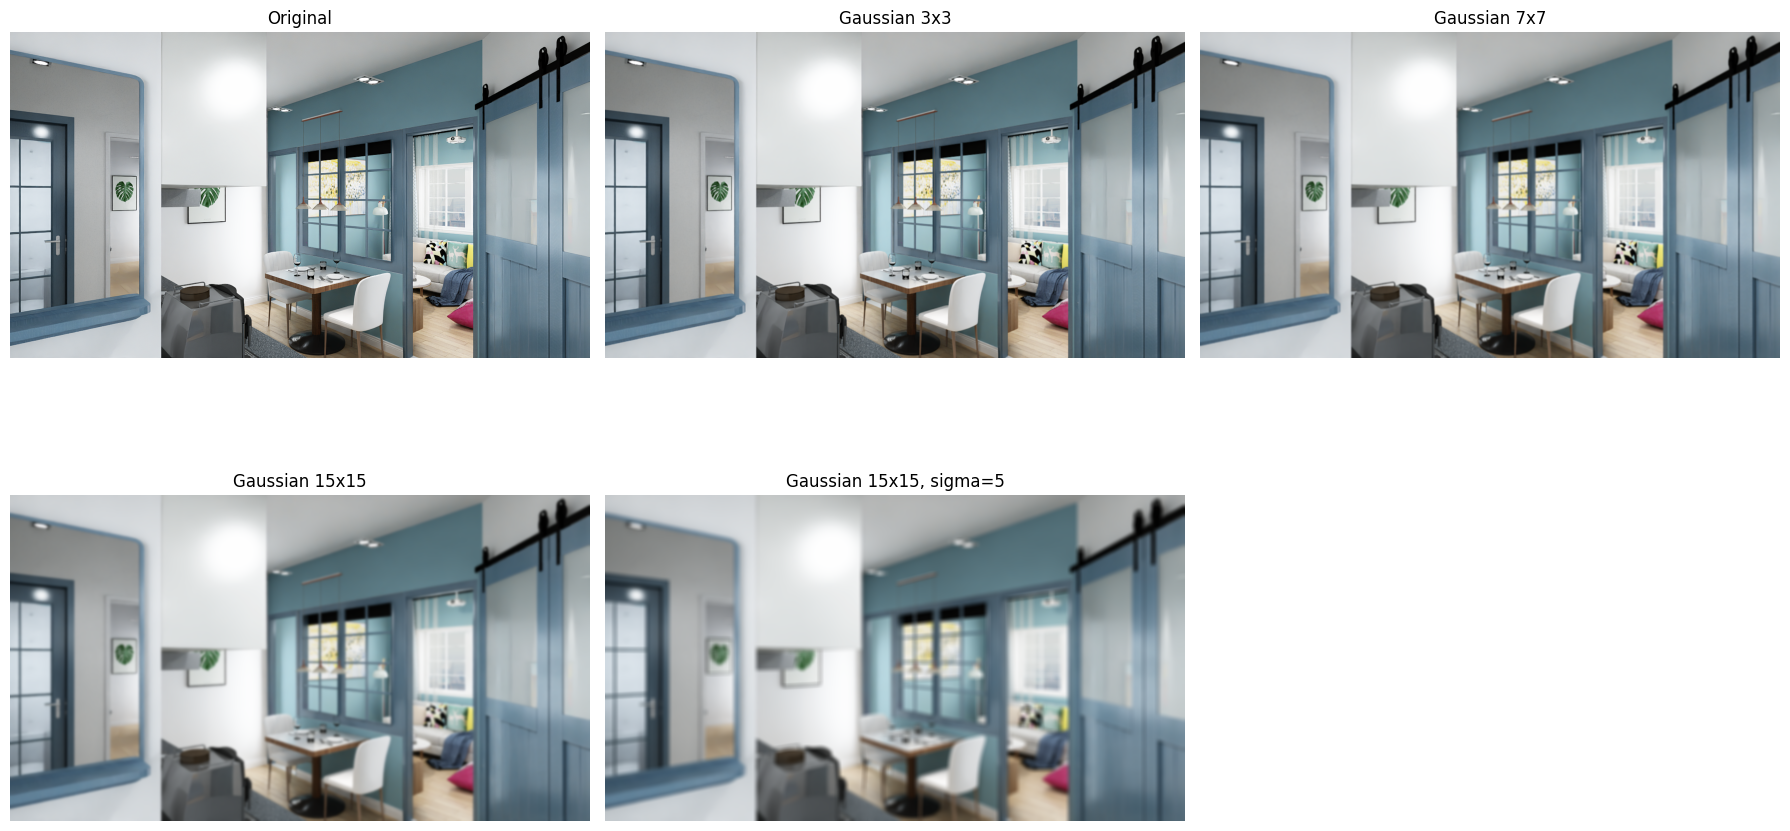

In [22]:
images = [
    image_rgb,
    blur_3,
    blur_7,
    blur_15,
    blur_sigma5,
]

titles = [
    "Original",
    "Gaussian 3x3",
    "Gaussian 7x7",
    "Gaussian 15x15",
    "Gaussian 15x15, sigma=5",
]

plt.figure(figsize=(18, 10))

for i, (img, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

여기까지 실습해봤다면 한번 질문해보자. 

`cv2.GaussianBlur(image_rgb, (3, 3), sigmaX=0, sigmaY=0)`  

에서, sigma 값이 커지면 어떻게 되나? 

(3,3)이 커지면 어떻게 되나? 



## Kernel Size와 $\sigma$의 관계

Gaussian 함수는 이론적으로 중심에서 무한히 멀리까지 이어진다.  
하지만 실제 이미지 처리에서는 무한한 크기의 커널을 사용할 수 없으므로, 일정 범위에서 Gaussian 함수를 잘라 유한한 크기의 커널로 사용한다.

Gaussian 분포의 값은 중심에서 멀어질수록 빠르게 감소한다. 일반적으로 Gaussian 분포의 대부분은 다음 범위 안에 포함된다.

$$
-3\sigma \le x \le 3\sigma
$$

즉, 중심을 기준으로 왼쪽과 오른쪽 각각 약 $3\sigma$ 범위까지 포함하면 Gaussian 함수의 주요 가중치를 대부분 사용할 수 있다.

따라서 1차원 커널의 크기는 대략 다음과 같이 설정할 수 있다.

$$
\text{kernel size}
\approx
2(3\sigma)+1
$$

이를 정리하면 다음과 같다.

$$
\text{kernel size}
\approx
6\sigma+1
$$

마지막에 $1$을 더하는 이유는 커널이 중심 원소를 포함하도록 홀수 크기를 사용하기 때문이다.

예를 들어 $\sigma=1$이면,

$$
\text{kernel size}
\approx
6(1)+1
=
7
$$

이므로 약 $7\times7$ 커널을 사용할 수 있다.

$\sigma=2$이면,

$$
\text{kernel size}
\approx
6(2)+1
=
13
$$

이므로 약 $13\times13$ 커널을 사용할 수 있다.

$\sigma=3$이면,

$$
\text{kernel size}
\approx
6(3)+1
=
19
$$

이므로 약 $19\times19$ 커널을 사용할 수 있다.

| $\sigma$ | 근사 kernel size |
|---:|---:|
| $0.5$ | $5$ |
| $1$ | $7$ |
| $2$ | $13$ |
| $3$ | $19$ |
| $5$ | $31$ |

이 관계는 절대적인 규칙이 아니라 Gaussian 함수의 주요 범위를 충분히 포함하기 위한 경험적인 기준이다.

커널 크기가 $\sigma$에 비해 너무 작으면 Gaussian 분포의 바깥 부분이 많이 잘리므로 원하는 blur 특성을 충분히 표현하지 못할 수 있다.

반대로 커널 크기가 지나치게 크면 결과 변화는 크지 않은데 계산량만 증가할 수 있다.